# Data Preprocessing

In [3]:
import os
from glob import glob
from PIL import Image
import random
import shutil
import tensorflow as tf
import numpy as np


IMG_SIZE = 224
TARGET_PER_CLASS = 300  
AUG_CLASSES = ['dom_la', 'trai_khoe', 'thoi_qua_den']
ORIG_DIR = '/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/train'
AUG_DIR = '/kaggle/working/data_aug/train'

os.makedirs(AUG_DIR, exist_ok=True)
for cls in ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']:
    os.makedirs(os.path.join(AUG_DIR, cls), exist_ok=True)

for cls in ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']:
    img_paths = []
    for ext in ['jpg', 'jpeg', 'png']:
        img_paths.extend(glob(f'{ORIG_DIR}/{cls}/*.{ext}'))

    print(f"Copying {len(img_paths)} ảnh từ {cls}...")

    for path in img_paths:
        filename = os.path.basename(path)
        shutil.copy(path, os.path.join(AUG_DIR, cls, filename))

def augment_image(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.rot90(img, k=random.randint(0, 3))
    return img

for cls in AUG_CLASSES:
    cls_path = os.path.join(AUG_DIR, cls)
    
    current_imgs = []
    for ext in ['jpg', 'jpeg', 'png']:
        current_imgs.extend(glob(f"{cls_path}/*.{ext}"))
    
    if not current_imgs:
        print(f"Không tìm thấy ảnh trong {cls_path}, kiểm tra lại copy ảnh gốc.")
        continue

    count = len(current_imgs)
    i = 0

    print(f"Augmenting: {cls} (hiện có {count} ảnh)")

    while count < TARGET_PER_CLASS:
        img_path = random.choice(current_imgs)
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img = tf.keras.preprocessing.image.img_to_array(img)
        img = tf.convert_to_tensor(img / 255.0)

        aug_img = augment_image(img)
        aug_img = tf.clip_by_value(aug_img, 0, 1) * 255
        aug_img = tf.cast(aug_img, tf.uint8).numpy()

        filename = f"{cls}_aug_{i}.jpg"
        Image.fromarray(aug_img.astype(np.uint8)).save(os.path.join(cls_path, filename))

        count += 1
        i += 1

    print(f"Đã tăng {cls} lên {count} ảnh")


📂 Copying 336 ảnh từ chay_la...
📂 Copying 97 ảnh từ dom_la...
📂 Copying 665 ảnh từ gi_sat...
📂 Copying 476 ảnh từ la_khoe...
📂 Copying 167 ảnh từ thoi_qua_den...
📂 Copying 133 ảnh từ trai_khoe...
⏳ Augmenting: dom_la (hiện có 300 ảnh)
✅ Đã tăng dom_la lên 300 ảnh
⏳ Augmenting: trai_khoe (hiện có 300 ảnh)
✅ Đã tăng trai_khoe lên 300 ảnh
⏳ Augmenting: thoi_qua_den (hiện có 300 ảnh)
✅ Đã tăng thoi_qua_den lên 300 ảnh


In [ ]:
import matplotlib.pyplot as plt

cls = AUG_CLASSES[0]
cls_path = os.path.join(AUG_DIR, cls)

# Lấy 1 ảnh gốc bất kỳ trong class này
img_path = random.choice(glob(f"{cls_path}/*.jpg"))
orig_img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
orig_arr = tf.keras.preprocessing.image.img_to_array(orig_img) / 255.0
orig_tensor = tf.convert_to_tensor(orig_arr)

# Tạo 3 ảnh augment
augmented_imgs = []
for _ in range(3):
    aug_img = augment_image(orig_tensor)
    aug_img = tf.clip_by_value(aug_img, 0, 1)
    augmented_imgs.append(aug_img.numpy())

# Hiển thị bằng matplotlib
plt.figure(figsize=(10, 5))

# Ảnh gốc
plt.subplot(1, 4, 1)
plt.imshow(orig_arr)
plt.title("Ảnh gốc")
plt.axis("off")

# Các ảnh augment
for i, aug in enumerate(augmented_imgs, start=1):
    plt.subplot(1, 4, i+1)
    plt.imshow(aug)
    plt.title(f"Aug {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input


COLOR_MODE = 'rgb'  
BATCH_SIZE = 32           
IMG_SIZE = 224            
NUM_CLASSES = 6

# train_set = tf.keras.utils.image_dataset_from_directory(
#     directory="/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/train",
#     labels="inferred",
#     label_mode="categorical",
#     class_names=['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe'],
#     color_mode='rgb',
#     batch_size=32,
#     image_size=(224, 224),
#     shuffle=True,
#     interpolation="bilinear",
#     seed=123
# )

train_set = tf.keras.utils.image_dataset_from_directory(
    directory=AUG_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe'],
    color_mode='rgb',
    batch_size=32,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    interpolation="bilinear",
    seed=123
)

val_set = tf.keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/val",
    labels="inferred",
    label_mode="categorical",
    class_names=['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe'],
    color_mode='rgb',
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    interpolation="bilinear",
    seed=123
)

test_set = tf.keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/test",
    labels="inferred",
    label_mode="categorical",
    class_names=['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe'],
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    interpolation="bilinear",
    seed=123
)

train_set = train_set.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_set = val_set.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_set = test_set.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)

Found 2377 files belonging to 6 classes.
Found 527 files belonging to 6 classes.
Found 274 files belonging to 6 classes.


In [5]:
import os

train_dir = AUG_DIR
chay_la_count = len(os.listdir(os.path.join(train_dir, "chay_la")))
dom_la_count = len(os.listdir(os.path.join(train_dir, "dom_la")))
gi_sat_count = len(os.listdir(os.path.join(train_dir, "gi_sat")))
la_khoe_count = len(os.listdir(os.path.join(train_dir, "la_khoe")))
thoi_qua_den_count = len(os.listdir(os.path.join(train_dir, 'thoi_qua_den')))
trai_khoe_count = len(os.listdir(os.path.join(train_dir, 'trai_khoe')))


print(f"Train set - CHAYLA: {chay_la_count}, DOMLA: {dom_la_count}, GISAT: {gi_sat_count}, LAKHOE: {la_khoe_count}, THOIQUADEN: {thoi_qua_den_count}, TRAIKHOE {trai_khoe_count}")

val_dir = "/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/val"
chay_la_count = len(os.listdir(os.path.join(val_dir, "chay_la")))
dom_la_count = len(os.listdir(os.path.join(val_dir, "dom_la")))
gi_sat_count = len(os.listdir(os.path.join(val_dir, "gi_sat")))
la_khoe_count = len(os.listdir(os.path.join(val_dir, "la_khoe")))
thoi_qua_den_count = len(os.listdir(os.path.join(val_dir, 'thoi_qua_den')))
trai_khoe_count = len(os.listdir(os.path.join(val_dir, 'trai_khoe')))

print(f"Val set - CHAYLA: {chay_la_count}, DOMLA: {dom_la_count}, GISAT: {gi_sat_count}, LAKHOE: {la_khoe_count}, THOIQUADEN: {thoi_qua_den_count}, TRAIKHOE {trai_khoe_count}")

test_dir = "/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/test"
chay_la_count = len(os.listdir(os.path.join(test_dir, "chay_la")))
dom_la_count = len(os.listdir(os.path.join(test_dir, "dom_la")))
gi_sat_count = len(os.listdir(os.path.join(test_dir, "gi_sat")))
la_khoe_count = len(os.listdir(os.path.join(test_dir, "la_khoe")))
thoi_qua_den_count = len(os.listdir(os.path.join(test_dir, 'thoi_qua_den')))
trai_khoe_count = len(os.listdir(os.path.join(test_dir, 'trai_khoe')))

print(f"Test set - CHAYLA: {chay_la_count}, DOMLA: {dom_la_count}, GISAT: {gi_sat_count}, LAKHOE: {la_khoe_count}, THOIQUADEN: {thoi_qua_den_count}, TRAIKHOE {trai_khoe_count}")



Train set - CHAYLA: 336, DOMLA: 300, GISAT: 665, LAKHOE: 476, THOIQUADEN: 300, TRAIKHOE 300
Val set - CHAYLA: 96, DOMLA: 23, GISAT: 190, LAKHOE: 133, THOIQUADEN: 47, TRAIKHOE 38
Test set - CHAYLA: 49, DOMLA: 13, GISAT: 96, LAKHOE: 72, THOIQUADEN: 25, TRAIKHOE 19


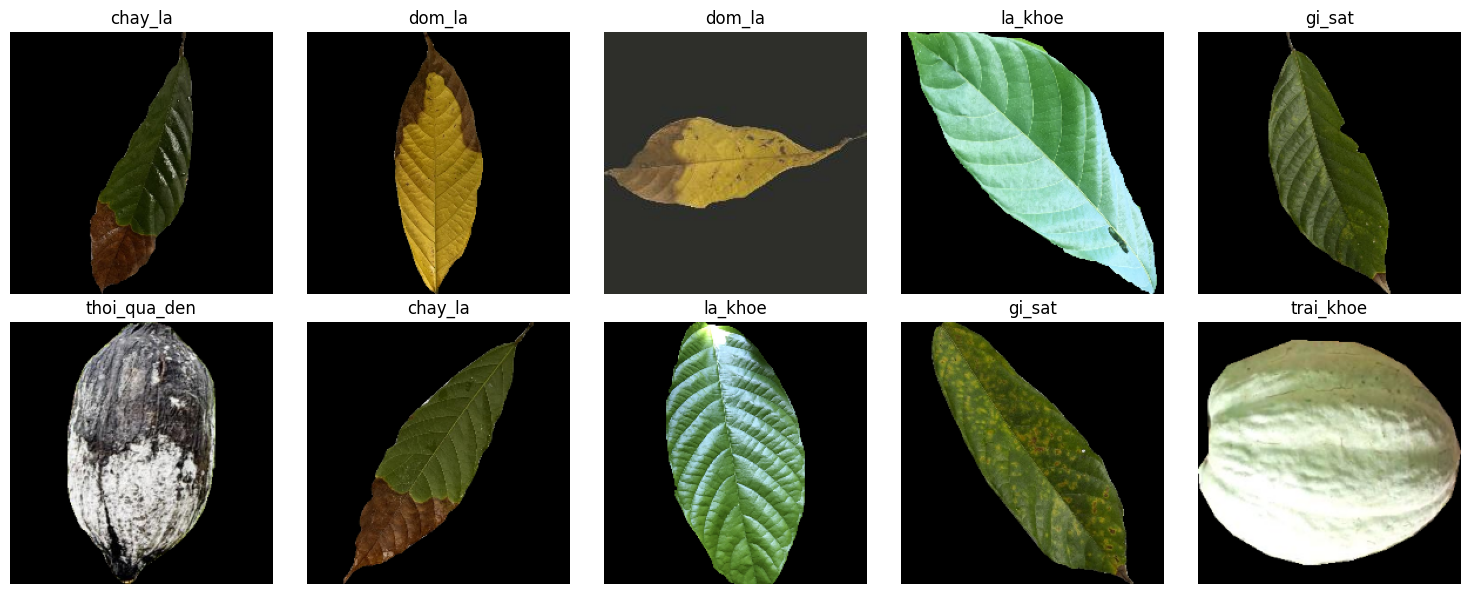

In [9]:
import matplotlib.pyplot as plt
import random
import numpy as np

images, labels = next(iter(train_set))
class_names = ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']


sample_indices = random.sample(range(len(images)), 10)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(sample_indices):
    plt.subplot(2, 5, i + 1)
    image = images[idx].numpy().astype("uint8")
    label_index = np.argmax(labels[idx].numpy())
    label_name = class_names[label_index]

    plt.imshow(image)
    plt.title(f"{label_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Effbo

In [10]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Base model EfficientNetB0
base_model  = EfficientNetB0(include_top=False, input_shape=(224,224,3), weights='imagenet')

# Freeze backbone để huấn luyện nhanh giai đoạn đầu
base_model.trainable=False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:

inputs = base_model.input
x = base_model.output
x = GlobalAveragePooling2D()(x)
# x = Dense(512, activation='relu')(x)
# x = Dropout(0.5)(x)
# x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)


In [12]:
from tensorflow.keras.models import Model

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 224, 224, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 224, 224, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_expand    

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [13]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [14]:
# Huấn luyện mô hình
history = model.fit(
    train_set,
    epochs=100,                  
    validation_data=val_set,
    callbacks=[early_stopping],  
    # class_weight=class_weights,
    verbose=1                   
)

Epoch 1/100


I0000 00:00:1749483397.763167      95 service.cc:148] XLA service 0x7e2644024440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749483397.764098      95 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1749483401.218735      95 cuda_dnn.cc:529] Loaded cuDNN version 90300


 5/75 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1903 - loss: 1.8167

I0000 00:00:1749483410.874357      95 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.5006 - loss: 1.2347 - val_accuracy: 0.9241 - val_loss: 0.4450
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8728 - loss: 0.4448 - val_accuracy: 0.9715 - val_loss: 0.2685
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9236 - loss: 0.3101 - val_accuracy: 0.9753 - val_loss: 0.1955
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9417 - loss: 0.2481 - val_accuracy: 0.9791 - val_loss: 0.1578
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9522 - loss: 0.2106 - val_accuracy: 0.9791 - val_loss: 0.1353
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9628 - loss: 0.1732 - val_accuracy: 0.9772 - val_loss: 0.1193
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9652 - loss: 0.1641 - val_accuracy: 0.9791 - val_loss: 0.1111
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9607 - loss: 0.1532 - val_accuracy: 0.9810 - val_l

In [15]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_set: 
    preds = model.predict(images, verbose=0)
    
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

class_names = ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']

print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

     chay_la       1.00      0.98      0.99        49
      dom_la       1.00      1.00      1.00        13
      gi_sat       0.99      1.00      0.99        96
     la_khoe       1.00      1.00      1.00        72
thoi_qua_den       1.00      1.00      1.00        25
   trai_khoe       1.00      1.00      1.00        19

    accuracy                           1.00       274
   macro avg       1.00      1.00      1.00       274
weighted avg       1.00      1.00      1.00       274



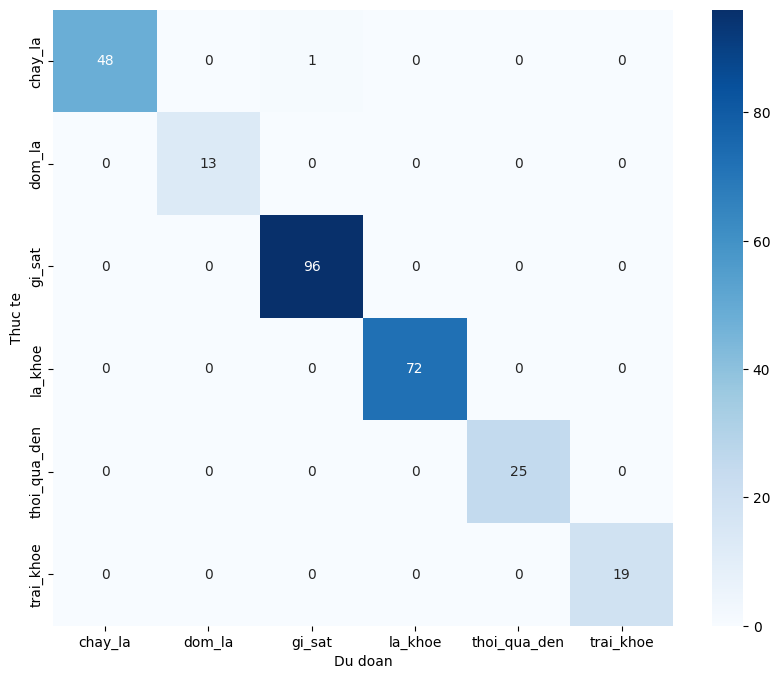

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
class_names = ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']


sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Du doan')
plt.ylabel('Thuc te');


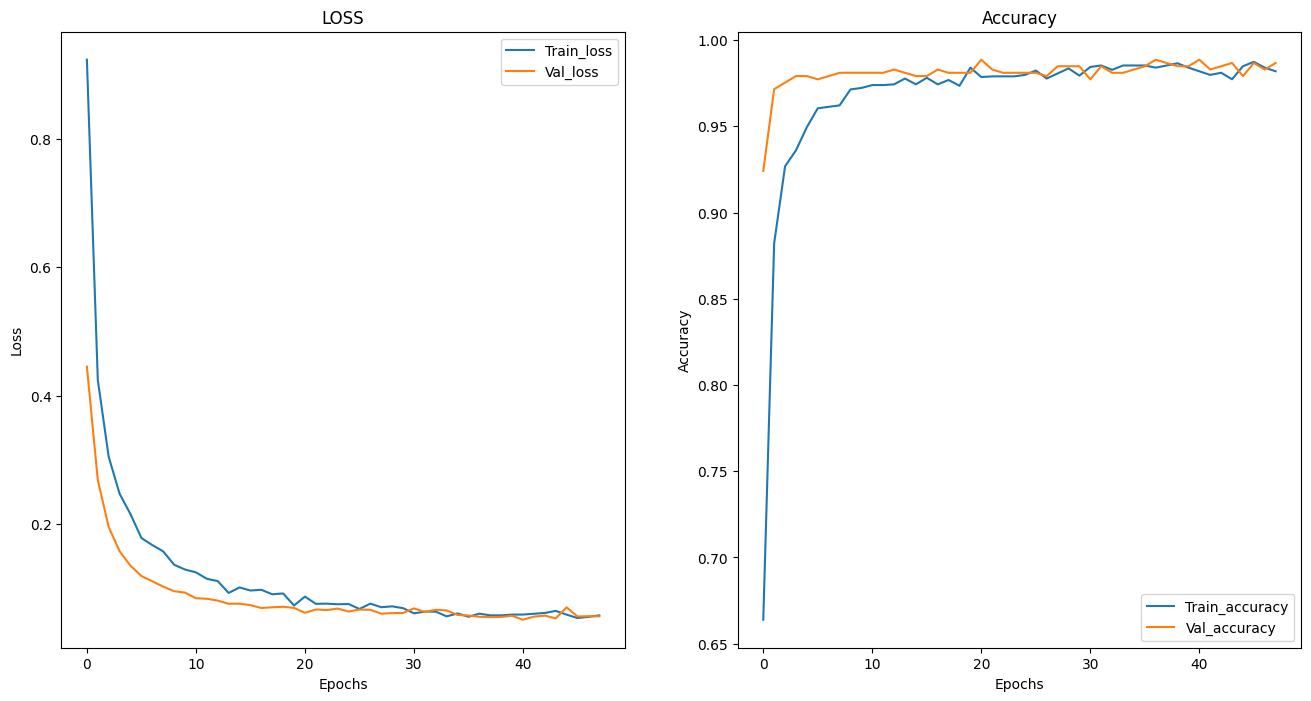

In [22]:
plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train_loss')
plt.plot(history.history['val_loss'], label='Val_loss')
plt.title('LOSS')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train_accuracy')
plt.plot(history.history['val_accuracy'], label='Val_accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

In [ ]:
for

## Test

In [15]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np

img_path = "/kaggle/input/cacao-disease-v2/dataset_main/test/gi_sat/IMG_1698_jpg.rf.d673486173ccb47b1ef1eb5ab2bc632a.png"

img = tf.keras.utils.load_img(img_path, target_size=(224, 224))

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

img_preprocessed = preprocess_input(img_array)

pred = model.predict(img_preprocessed)

class_names = ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']
pred_class = np.argmax(pred[0])
confidence = pred[0][pred_class]

print(f"Dự đoán: {class_names[pred_class]} ({confidence*100:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Dự đoán: gi_sat (99.93%)


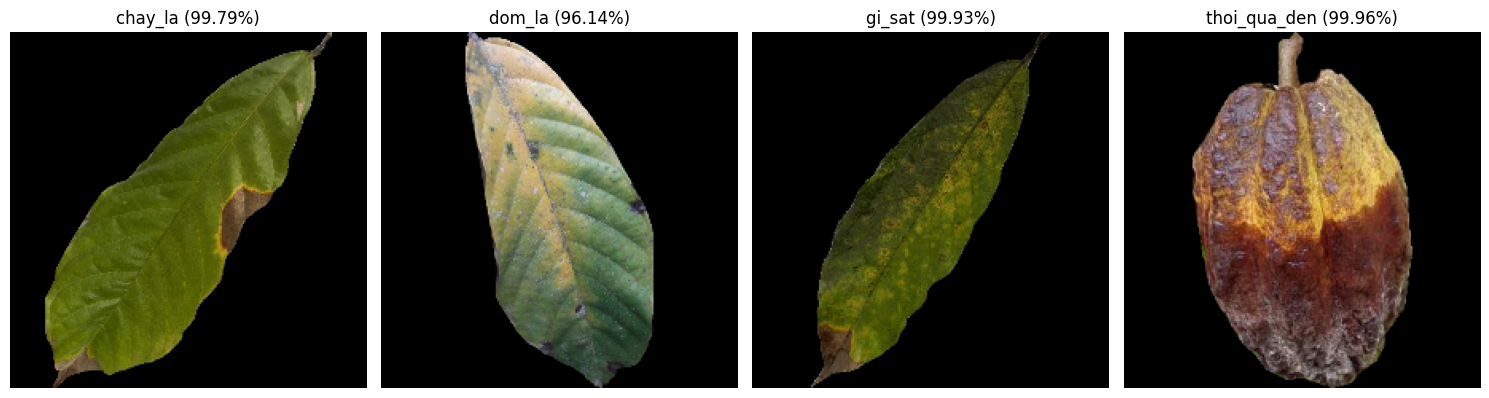

In [16]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

# --- Thông tin ---
# --- Cấu hình ---
img_paths = [
    "/kaggle/input/cacao-disease-v2/dataset_main/test/chay_la/IMG_0757_jpg.rf.7d999ae6ffb6d4eb7ce139deebda026a_crop.png",
    "/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/test/dom_la/ID_yXnHjb_jpg.rf.61d2bafb4db94d89d5af9d1352270dac_crop.png",
    "/kaggle/input/cacao-disease-v2/dataset_main/test/gi_sat/IMG_1698_jpg.rf.d673486173ccb47b1ef1eb5ab2bc632a.png",
    "/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/test/thoi_qua_den/black_pod_rot_17_jpg.rf.cac40c62fa03de654e183de91ad6e277.png"
]
class_names = ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']

# --- Tiền xử lý & Dự đoán ---
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, path in enumerate(img_paths):
    # Load ảnh
    img = tf.keras.utils.load_img(path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_batch)

    # Dự đoán
    preds = model.predict(img_preprocessed, verbose=0)[0]  # model phải là mô hình có Dense(4, softmax)
    pred_class_idx = np.argmax(preds)
    pred_class_name = class_names[pred_class_idx]
    confidence = preds[pred_class_idx]

    # Hiển thị
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{pred_class_name} ({confidence*100:.2f}%)")

plt.tight_layout()
plt.show()


In [19]:
model.save("saved_model/cacao_classifier/efficientnet_b0_aug.keras") 

FileNotFoundError: [Errno 2] No such file or directory: 'saved_model/cacao_classifier/efficientnet_b0_aug.keras'

2025-06-14 03:59:18.791021: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749873559.006330      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749873559.066591      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


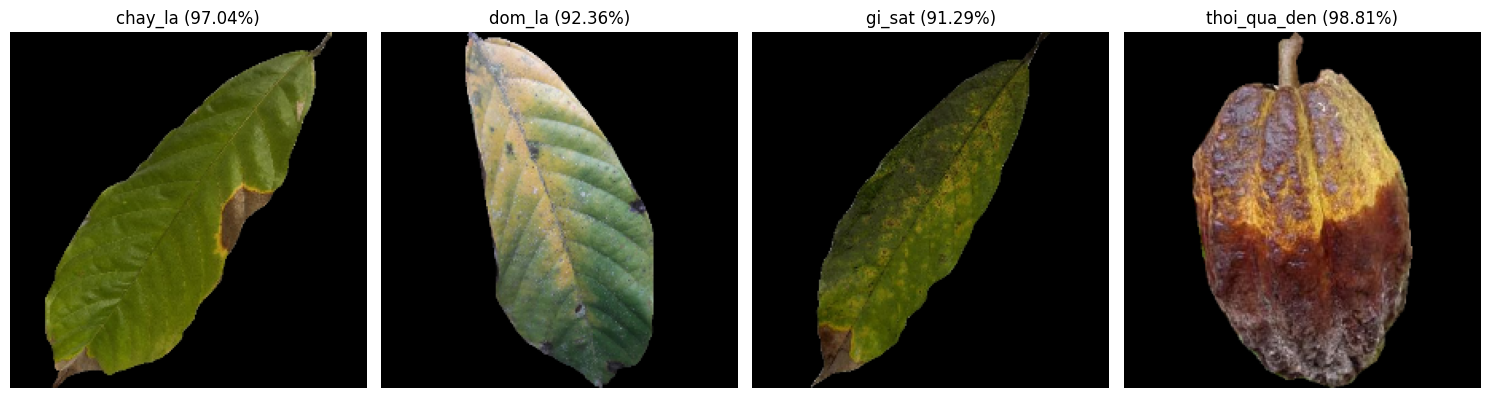

In [1]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

img_paths = [
    "/kaggle/input/cacao-disease-v2/dataset_main/test/chay_la/IMG_0757_jpg.rf.7d999ae6ffb6d4eb7ce139deebda026a_crop.png",
    "/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/test/dom_la/ID_yXnHjb_jpg.rf.61d2bafb4db94d89d5af9d1352270dac_crop.png",
    "/kaggle/input/cacao-disease-v2/dataset_main/test/gi_sat/IMG_1698_jpg.rf.d673486173ccb47b1ef1eb5ab2bc632a.png",
    "/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/test/thoi_qua_den/black_pod_rot_17_jpg.rf.cac40c62fa03de654e183de91ad6e277.png"
]
custom_predictions = [
    ("chay_la", 0.9704),
    ("dom_la", 0.9236),
    ("gi_sat", 0.9129),
    ("thoi_qua_den", 0.9881)
]

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, (path, (label, conf)) in enumerate(zip(img_paths, custom_predictions)):
    img = tf.keras.utils.load_img(path, target_size=(224, 224))
    
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{label} ({conf*100:.2f}%)")

plt.tight_layout()
plt.show()

In [20]:
import os

save_path = "saved_model/cacao_classifier"
os.makedirs(save_path, exist_ok=True)

model.save(os.path.join(save_path, "efficientnet_b0_aug.keras"))


In [21]:
import tensorflow as tf

model = tf.keras.models.load_model("saved_model/cacao_classifier/efficientnet_b0_aug.keras")


In [22]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()


Saved artifact at '/tmp/tmpfdyhxprt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134453461472784: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134453461475664: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134454114527632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134454114530320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134454114525136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134454114528592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134454114526288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134454114527440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134454114531664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134454114532624: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1749470920.880367      35 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1749470920.880402      35 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1749470921.076834      35 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


In [23]:
with open("efficientnet_b0_aug.tflite", "wb") as f:
    f.write(tflite_model)


# Nasnet Mobile

In [4]:
import os
from glob import glob
from PIL import Image
import random
import shutil
import tensorflow as tf
import numpy as np


IMG_SIZE = 224
TARGET_PER_CLASS = 300  
AUG_CLASSES = ['dom_la', 'trai_khoe', 'thoi_qua_den']  
ORIG_DIR = '/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/train'
AUG_DIR = '/kaggle/working/data_aug/train'

os.makedirs(AUG_DIR, exist_ok=True)
for cls in ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']:
    os.makedirs(os.path.join(AUG_DIR, cls), exist_ok=True)

for cls in ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']:
    img_paths = []
    for ext in ['jpg', 'jpeg', 'png']:
        img_paths.extend(glob(f'{ORIG_DIR}/{cls}/*.{ext}'))

    print(f"Copying {len(img_paths)} ảnh từ {cls}...")

    for path in img_paths:
        filename = os.path.basename(path)
        shutil.copy(path, os.path.join(AUG_DIR, cls, filename))

def augment_image(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.rot90(img, k=random.randint(0, 3))
    return img

for cls in AUG_CLASSES:
    cls_path = os.path.join(AUG_DIR, cls)
    
    current_imgs = []
    for ext in ['jpg', 'jpeg', 'png']:
        current_imgs.extend(glob(f"{cls_path}/*.{ext}"))
    
    if not current_imgs:
        print(f"Không tìm thấy ảnh trong {cls_path}, kiểm tra lại copy ảnh gốc.")
        continue

    count = len(current_imgs)
    i = 0

    print(f"⏳ Augmenting: {cls} (hiện có {count} ảnh)")

    while count < TARGET_PER_CLASS:
        img_path = random.choice(current_imgs)
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img = tf.keras.preprocessing.image.img_to_array(img)
        img = tf.convert_to_tensor(img / 255.0)

        aug_img = augment_image(img)
        aug_img = tf.clip_by_value(aug_img, 0, 1) * 255
        aug_img = tf.cast(aug_img, tf.uint8).numpy()

        filename = f"{cls}_aug_{i}.jpg"
        Image.fromarray(aug_img.astype(np.uint8)).save(os.path.join(cls_path, filename))

        count += 1
        i += 1

    print(f"Đã tăng {cls} lên {count} ảnh")


📂 Copying 336 ảnh từ chay_la...
📂 Copying 97 ảnh từ dom_la...
📂 Copying 665 ảnh từ gi_sat...
📂 Copying 476 ảnh từ la_khoe...
📂 Copying 167 ảnh từ thoi_qua_den...
📂 Copying 133 ảnh từ trai_khoe...
⏳ Augmenting: dom_la (hiện có 97 ảnh)


I0000 00:00:1749484668.148243      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ Đã tăng dom_la lên 300 ảnh
⏳ Augmenting: trai_khoe (hiện có 133 ảnh)
✅ Đã tăng trai_khoe lên 300 ảnh
⏳ Augmenting: thoi_qua_den (hiện có 167 ảnh)
✅ Đã tăng thoi_qua_den lên 300 ảnh


In [5]:
import tensorflow as tf
from tensorflow.keras.applications.nasnet import NASNetMobile, preprocess_input
from tensorflow.keras import layers, models, optimizers, callbacks


COLOR_MODE = 'rgb'  
BATCH_SIZE = 32          
IMG_SIZE = 224           
NUM_CLASSES = 6

# train_set = tf.keras.utils.image_dataset_from_directory(
#     directory="/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/train",
#     labels="inferred",
#     label_mode="categorical",
#     class_names=['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe'],
#     color_mode=COLOR_MODE,
#     batch_size=32,
#     image_size=(IMG_SIZE, IMG_SIZE),
#     shuffle=True,
#     interpolation="bilinear",
#     # validation_split=0.2,
#     # subset="training",
#     seed=123
# )

train_set = tf.keras.utils.image_dataset_from_directory(
    directory=AUG_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe'],
    color_mode='rgb',
    batch_size=32,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    interpolation="bilinear",
    seed=123
)

val_set = tf.keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/val",
    labels="inferred",
    label_mode="categorical",
    class_names=['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe'],
    color_mode=COLOR_MODE,
    batch_size=32,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    interpolation="bilinear",
)

test_set = tf.keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/test",
    labels="inferred",
    label_mode="categorical",
    class_names=['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe'],
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    interpolation="bilinear",
    seed=123
)


train_set = train_set.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_set = val_set.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_set = test_set.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)


Found 2377 files belonging to 6 classes.
Found 527 files belonging to 6 classes.
Found 274 files belonging to 6 classes.


In [6]:
# from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

# from tensorflow.keras.models import Model

# base_model = NASNetMobile(
#     input_shape=(IMG_SIZE, IMG_SIZE, 3),
#     include_top=False,
#     weights='imagenet',
# )

# # Đóng băng nếu muốn fine-tune sau
# base_model.trainable = False

# # Classification head
# inputs = base_model.input
# x = base_model.output
# # x = layers.Dense(128, activation='relu')(base_model.output)
# x = layers.GlobalAveragePooling2D()(x)
# x = layers.Dropout(0.5)(x)
# output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# model = models.Model(inputs=base_model.input, outputs=output)

# model.summary()


19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv1 (Conv2D)       │ (None, 111, 111, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn1                  │ (None, 111, 111, 32)   │            128 │ stem_conv1[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 111, 111, 32)   │              0 │ stem_bn1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reduction_conv_1_stem_1   │ (None, 111, 111, 11)   │            352 │ activation[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reduction_bn_1_stem_1     │ (None, 111, 111, 11)   │             44 │ reduction_conv_1_stem… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 111, 111, 11)   │              0 │ reduction_bn_1_stem_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 111, 111, 32)   │              0 │ stem_bn1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_pad_red… │ (None, 115, 115, 11)   │              0 │ activation_1[0][0]     │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_pad_red… │ (None, 117, 117, 32)   │              0 │ activation_3[0][0]     │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_reducti… │ (None, 56, 56, 11)     │            396 │ separable_conv_1_pad_… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_reducti… │ (None, 56, 56, 11)     │          1,920 │ separable_conv_1_pad_… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_bn_redu… │ (None, 56, 56, 11)     │             44 │ separable_conv_1_redu… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_bn_redu… │ (None, 56, 56, 11)     │             44 │ separable_conv_1_redu… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 56, 56, 11)     │              0 │ separable_conv_1_bn_r… │
├──────────────────────

 Total params: 4,276,058 (16.31 MB)

 Trainable params: 6,342 (24.77 KB)

 Non-trainable params: 4,269,716 (16.29 MB)

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.models import Model

base_model = NASNetMobile(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  

x = GlobalAveragePooling2D()(base_model.output)
# x = layers.Dense(512, activation='relu')(x)
# x = layers.Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# x = layers.Dropout(0.3)(x)
# outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.summary()

In [7]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


In [8]:
history_2 = model.fit(
    train_set, 
    validation_data=val_set, 
    epochs=100, 
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100


I0000 00:00:1749484813.088247      96 service.cc:148] XLA service 0x780c84003590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749484813.089332      96 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1749484821.002532      96 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/75 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.1641 - loss: 2.0996  

I0000 00:00:1749484827.986865      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.4367 - loss: 1.4340 - val_accuracy: 0.9108 - val_loss: 0.4971
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.8047 - loss: 0.5741 - val_accuracy: 0.9450 - val_loss: 0.3135
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.8826 - loss: 0.3799 - val_accuracy: 0.9507 - val_loss: 0.2469
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9027 - loss: 0.3134 - val_accuracy: 0.9620 - val_loss: 0.2042
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9291 - loss: 0.2569 - val_accuracy: 0.9639 - val_loss: 0.1787
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9304 - loss: 0.2348 - val_accuracy: 0.9658 - val_loss: 0.1611
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9385 - loss: 0.2105 - val_accuracy: 0.9658 - val_loss: 0.1488
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9482 - loss: 0.1997 - val_accuracy: 0.9639 - val_l

In [9]:
from sklearn.metrics import classification_report
import numpy as np

y_true_2 = []
y_pred_2 = []

for images, labels in test_set:  
    preds = model.predict(images, verbose=0)
    
    y_true_2.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_2.extend(np.argmax(preds, axis=1))

class_names = ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']

print(classification_report(y_true_2, y_pred_2, target_names=class_names))


              precision    recall  f1-score   support

     chay_la       1.00      0.96      0.98        49
      dom_la       1.00      0.92      0.96        13
      gi_sat       0.99      1.00      0.99        96
     la_khoe       0.97      1.00      0.99        72
thoi_qua_den       1.00      0.88      0.94        25
   trai_khoe       0.86      1.00      0.93        19

    accuracy                           0.98       274
   macro avg       0.97      0.96      0.96       274
weighted avg       0.98      0.98      0.98       274



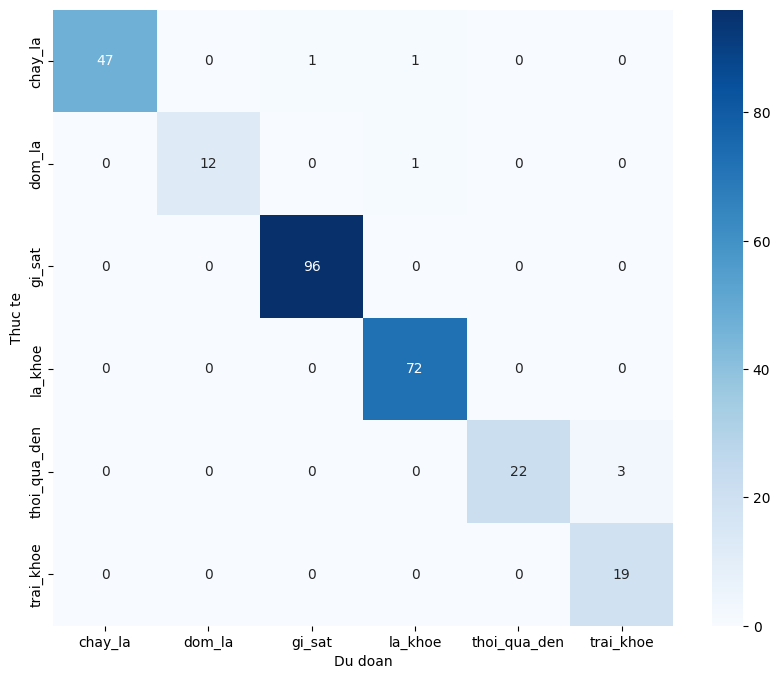

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
class_names = ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']


sns.heatmap(confusion_matrix(y_true_2, y_pred_2), annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Du doan')
plt.ylabel('Thuc te');


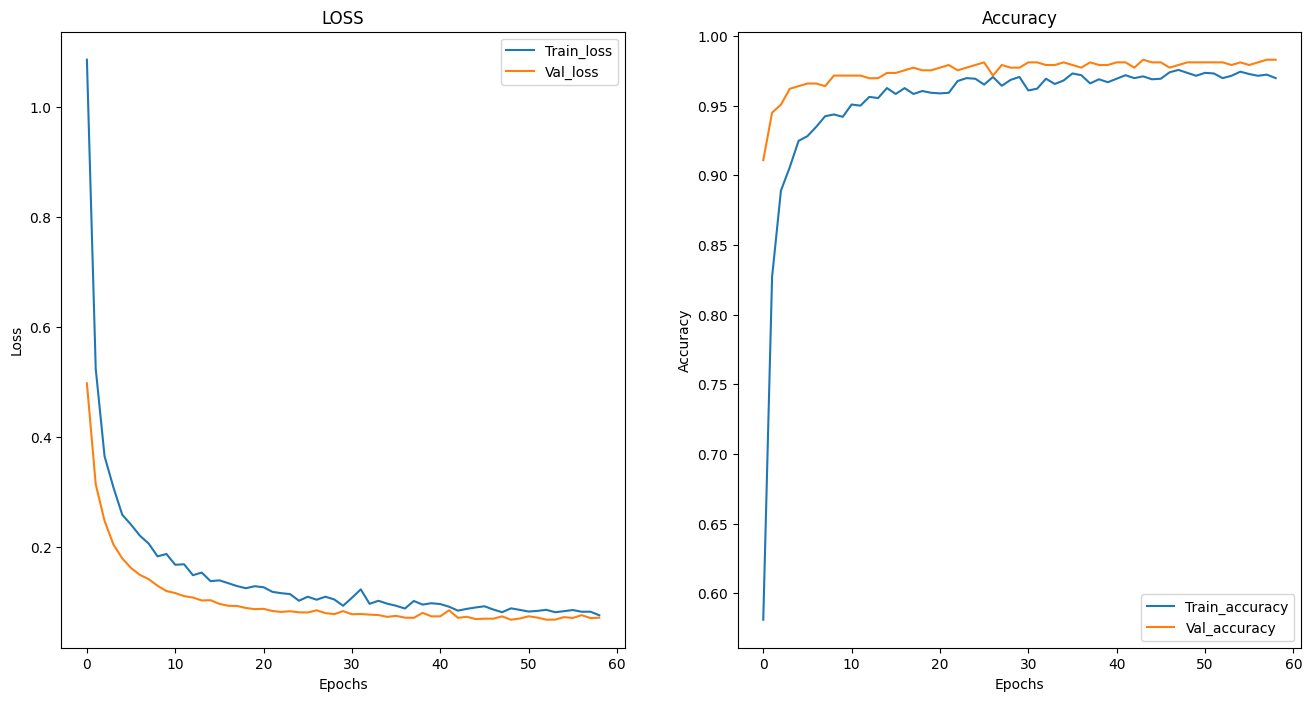

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
plt.plot(history_2.history['loss'], label='Train_loss')
plt.plot(history_2.history['val_loss'], label='Val_loss')
plt.title('LOSS')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_2.history['accuracy'], label='Train_accuracy')
plt.plot(history_2.history['val_accuracy'], label='Val_accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

In [17]:
print(model.input.shape)


(None, 224, 224, 3)


## 🤖Test 

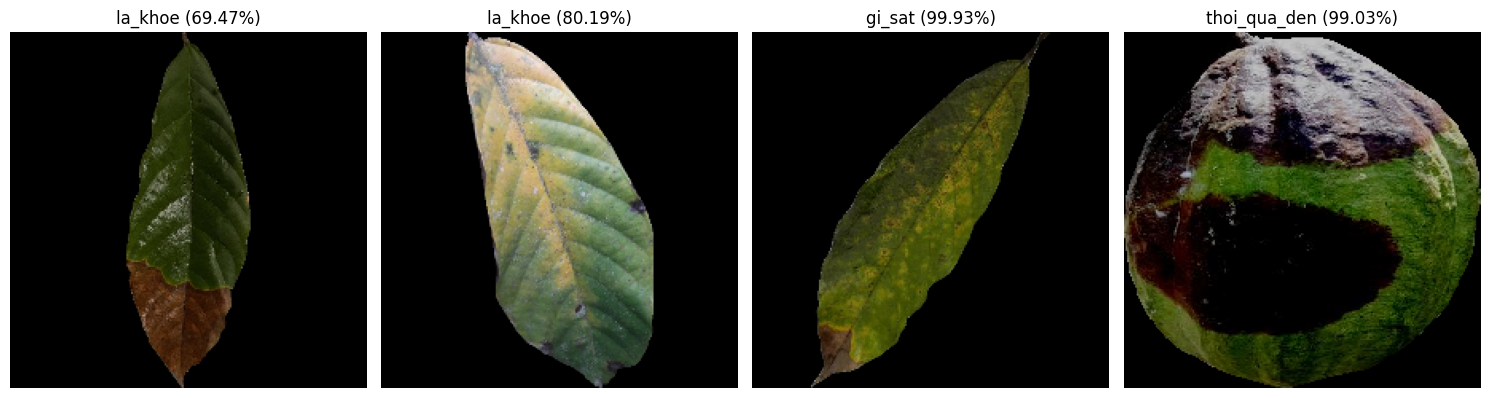

In [19]:
import tensorflow as tf
from tensorflow.keras.applications.nasnet import NASNetMobile, preprocess_input
import numpy as np
import matplotlib.pyplot as plt

img_paths = [
    "/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/test/chay_la/IMG_0674_jpg.rf.f6794c5618bdb9e804d9c054706db781_crop.png",
    "/kaggle/input/full-data-cocoa-v2/data_cocoa_v2/test/dom_la/ID_yXnHjb_jpg.rf.61d2bafb4db94d89d5af9d1352270dac_crop.png",
    "/kaggle/input/cacao-disease-v2/dataset_main/test/gi_sat/IMG_1698_jpg.rf.d673486173ccb47b1ef1eb5ab2bc632a.png",
    "/kaggle/input/full-data-cocoa/data_cocoa_v1/test/thoi_qua_den/black_pod_rot_634_jpg.rf.d09732c7a99d3fe4a900bc4c535a8d4c.png"
]
class_names = ['chay_la', 'dom_la', 'gi_sat', 'la_khoe', 'thoi_qua_den', 'trai_khoe']

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, path in enumerate(img_paths):
    img = tf.keras.utils.load_img(path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_batch) 

    preds = model.predict(img_preprocessed, verbose=0)[0]  
    pred_class_idx = np.argmax(preds)
    pred_class_name = class_names[pred_class_idx]
    confidence = preds[pred_class_idx]

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{pred_class_name} ({confidence*100:.2f}%)")

plt.tight_layout()
plt.show()


In [20]:
model.save("saved_model/cacao_classifier/NASNetMobile_aug.h5")


In [27]:
import os

save_path = "saved_model/cacao_classifier"
os.makedirs(save_path, exist_ok=True)

model.save(os.path.join(save_path, "NASNetMobile_aug.keras"))


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("saved_model/cacao_classifier/NASNetMobile_aug.keras")


In [28]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()


Saved artifact at '/tmp/tmpdbf9bemx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  131998613370640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131998613371024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131998613372560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131998613371792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131998613371408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131998613370832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131998613371216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131999601770768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131998613371984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131998613372176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13199960177518

W0000 00:00:1749486329.769634      35 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1749486329.769672      35 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [29]:
with open("NASNetMobile_aug.tflite", "wb") as f:
    f.write(tflite_model)


# Test with another Data set

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/cacao-diseases/cacao_diseases/cacao_photos'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install split-folders

In [2]:
!pip install -q split-folders

import splitfolders, shutil, os

SRC = "/kaggle/input/cacao-diseases/cacao_diseases/cacao_photos"
OUT = "/kaggle/working/cacao_split"  # thư mục ghi được

# nếu chạy lại nhiều lần, xoá output cũ
if os.path.exists(OUT):
    shutil.rmtree(OUT)

splitfolders.ratio(
    SRC,
    output=OUT,
    seed=42,
    ratio=(0.7, 0.2, 0.1),  # train/val/test
    move=False              # BẮT BUỘC: chỉ copy, không move
)

print("Done! Dữ liệu ở:", OUT)

Copying files: 4390 files [00:42, 103.42 files/s]

Done! Dữ liệu ở: /kaggle/working/cacao_split


In [3]:
import os
from glob import glob
from PIL import Image
import random
import shutil
import tensorflow as tf
import numpy as np

# ========== THÔNG SỐ ==========
IMG_SIZE = 224
TARGET_PER_CLASS = 500
AUG_CLASSES = ['pod_borer']
ORIG_DIR = '/kaggle/working/cacao_split/train'
AUG_DIR = '/kaggle/working/data_split_aug/train'

# ========== TẠO FOLDER ==========
os.makedirs(AUG_DIR, exist_ok=True)
for cls in ['pod_borer', 'black_pod_rot', 'healthy']:
    os.makedirs(os.path.join(AUG_DIR, cls), exist_ok=True)

# ========== COPY ẢNH GỐC ==========
for cls in ['pod_borer', 'black_pod_rot', 'healthy']:
    img_paths = []
    for ext in ['jpg', 'jpeg', 'png']:
        img_paths.extend(glob(f'{ORIG_DIR}/{cls}/*.{ext}'))

    print(f"📂 Copying {len(img_paths)} ảnh từ {cls}...")
    for path in img_paths:
        shutil.copy(path, os.path.join(AUG_DIR, cls, os.path.basename(path)))

# ========== HÀM LOAD ẢNH (không dùng keras) ==========
def load_image_pil(path, size):
    img = Image.open(path).convert("RGB").resize((size, size), Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0  # [0,1]
    return tf.convert_to_tensor(arr)  # HWC, float32

# ========== HÀM AUGMENT ==========
def augment_image(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.rot90(img, k=random.randint(0, 3))
    return img

# ========== THỰC HIỆN AUGMENT ==========
for cls in AUG_CLASSES:
    cls_path = os.path.join(AUG_DIR, cls)

    current_imgs = []
    for ext in ['jpg', 'jpeg', 'png']:
        current_imgs.extend(glob(f"{cls_path}/*.{ext}"))

    if not current_imgs:
        print(f"❌ Không tìm thấy ảnh trong {cls_path}")
        continue

    count = len(current_imgs)
    i = 0
    print(f"⏳ Augmenting: {cls} (hiện có {count} ảnh)")

    while count < TARGET_PER_CLASS:
        img_path = random.choice(current_imgs)

        img = load_image_pil(img_path, IMG_SIZE)
        aug_img = augment_image(img)
        aug_img = tf.clip_by_value(aug_img, 0.0, 1.0)
        aug_img = tf.cast(aug_img * 255.0, tf.uint8).numpy()

        filename = f"{cls}_aug_{i}.jpg"
        Image.fromarray(aug_img).save(os.path.join(cls_path, filename))

        count += 1
        i += 1

    print(f"✅ Đã tăng {cls} lên {count} ảnh")

2025-10-10 02:38:51.358476: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760063931.606533      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760063931.673319      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


📂 Copying 72 ảnh từ pod_borer...
📂 Copying 660 ảnh từ black_pod_rot...
📂 Copying 2340 ảnh từ healthy...
⏳ Augmenting: pod_borer (hiện có 72 ảnh)


I0000 00:00:1760063946.985268      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ Đã tăng pod_borer lên 500 ảnh


In [10]:
import tensorflow as tf
from tensorflow.keras.applications.nasnet import NASNetMobile, preprocess_input
from tensorflow.keras import layers, models, optimizers, callbacks


# Định nghĩa các hằng số
COLOR_MODE = 'rgb'  # hoặc 'rgb' tùy thuộc vào dữ liệu
BATCH_SIZE = 32           # Có thể điều chỉnh theo nhu cầu
IMG_SIZE = 224            # Kích thước ảnh (224x224 là phổ biến cho các mô hình như ResNet)
NUM_CLASSES = 3


train_set = tf.keras.utils.image_dataset_from_directory(
    directory=AUG_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=['pod_borer', 'black_pod_rot', 'healthy'],
    color_mode='rgb',
    batch_size=32,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    interpolation="bilinear",
    seed=123
)

val_set = tf.keras.utils.image_dataset_from_directory(
    directory="/kaggle/working/cacao_split/val",
    labels="inferred",
    label_mode="categorical",
    class_names=['pod_borer', 'black_pod_rot', 'healthy'],
    color_mode=COLOR_MODE,
    batch_size=32,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    interpolation="bilinear",
)

# Tạo tập dữ liệu kiểm tra
test_set = tf.keras.utils.image_dataset_from_directory(
    directory="/kaggle/working/cacao_split/test",
    labels="inferred",
    label_mode="categorical",
    class_names=['pod_borer', 'black_pod_rot', 'healthy'],
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    interpolation="bilinear",
    seed=123
)


# Apply preprocessing
train_set = train_set.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_set = val_set.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_set = test_set.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(tf.data.AUTOTUNE)


Found 3500 files belonging to 3 classes.
Found 876 files belonging to 3 classes.
Found 442 files belonging to 3 classes.


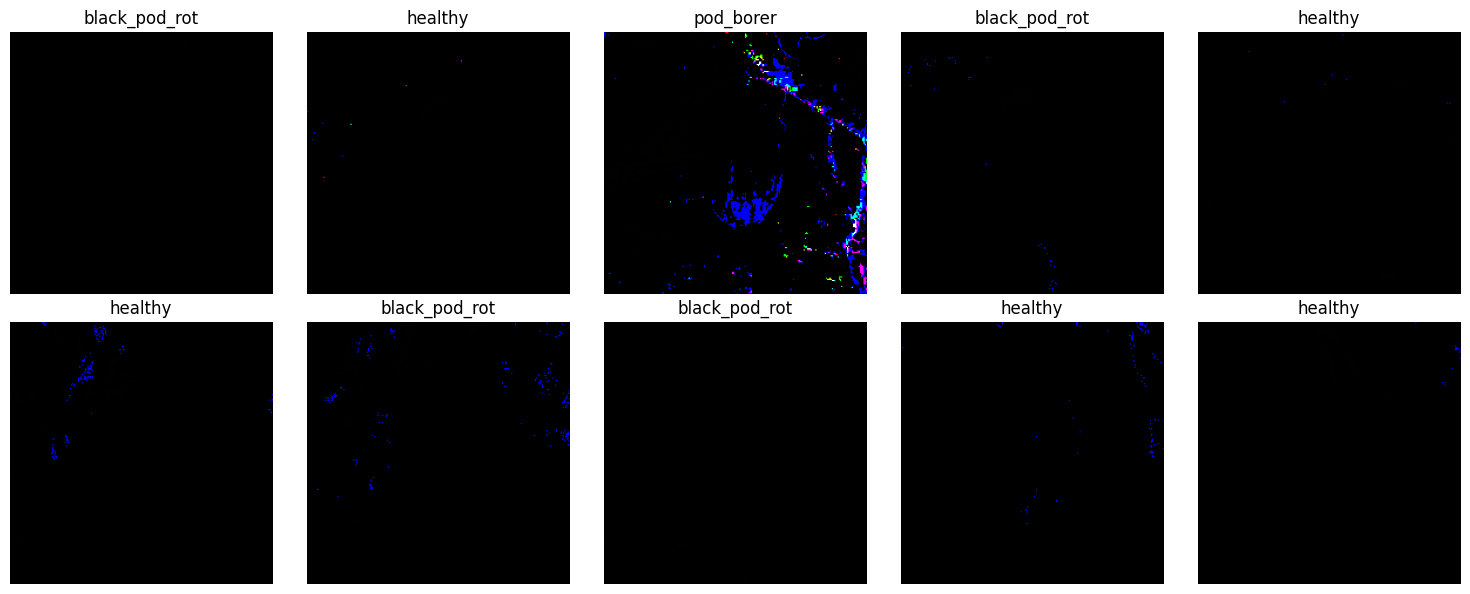

In [11]:
import matplotlib.pyplot as plt
import random
import numpy as np

images, labels = next(iter(train_set))
class_names = ['pod_borer', 'black_pod_rot', 'healthy']


# Lấy ngẫu nhiên 10 chỉ số ảnh trong batch
sample_indices = random.sample(range(len(images)), 10)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(sample_indices):
    plt.subplot(2, 5, i + 1)
    image = images[idx].numpy().astype("uint8")
    label_index = np.argmax(labels[idx].numpy())
    label_name = class_names[label_index]

    plt.imshow(image)
    plt.title(f"{label_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Base model EfficientNetB0
base_model  = EfficientNetB0(include_top=False, input_shape=(224,224,3), weights='imagenet')

# Freeze backbone để huấn luyện nhanh giai đoạn đầu
base_model.trainable=False

In [13]:

inputs = base_model.input
x = base_model.output
x = GlobalAveragePooling2D()(x)
# x = Dense(512, activation='relu')(x)
# x = Dropout(0.5)(x)
# x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

from tensorflow.keras.models import Model

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_2 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_1           │ (None, 224, 224, 3)    │              7 │ rescaling_2[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_3 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_3[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# bien dich model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Huấn luyện mô hình
history = model.fit(
    train_set,
    epochs=100,                  # Số epoch tối đa
    validation_data=val_set,
    callbacks=[early_stopping],  # Sử dụng EarlyStopping
    # class_weight=class_weights,
    verbose=1                    # Hiển thị tiến trình huấn luyện
)

Epoch 1/100


I0000 00:00:1760064728.972702     106 service.cc:148] XLA service 0x7ef89c05eeb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760064728.975705     106 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1760064731.334185     106 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/110 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4635 - loss: 1.0599  

I0000 00:00:1760064740.611810     106 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 ━━━━━━━━━━━━━━━━━━━━ 61s 307ms/step - accuracy: 0.6523 - loss: 0.8997 - val_accuracy: 0.7626 - val_loss: 0.7074
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6660 - loss: 0.8686 - val_accuracy: 0.7626 - val_loss: 0.7163
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6634 - loss: 0.8743 - val_accuracy: 0.7626 - val_loss: 0.7162
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6666 - loss: 0.8702 - val_accuracy: 0.7626 - val_loss: 0.7090
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6666 - loss: 0.8620 - val_accuracy: 0.7626 - val_loss: 0.7130
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6659 - loss: 0.8597 - val_accuracy: 0.7626 - val_loss: 0.7048
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6668 - loss: 0.8596 - val_accuracy: 0.7626 - val_loss: 0.7206
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6671 - loss: 0.8599 - val_accura

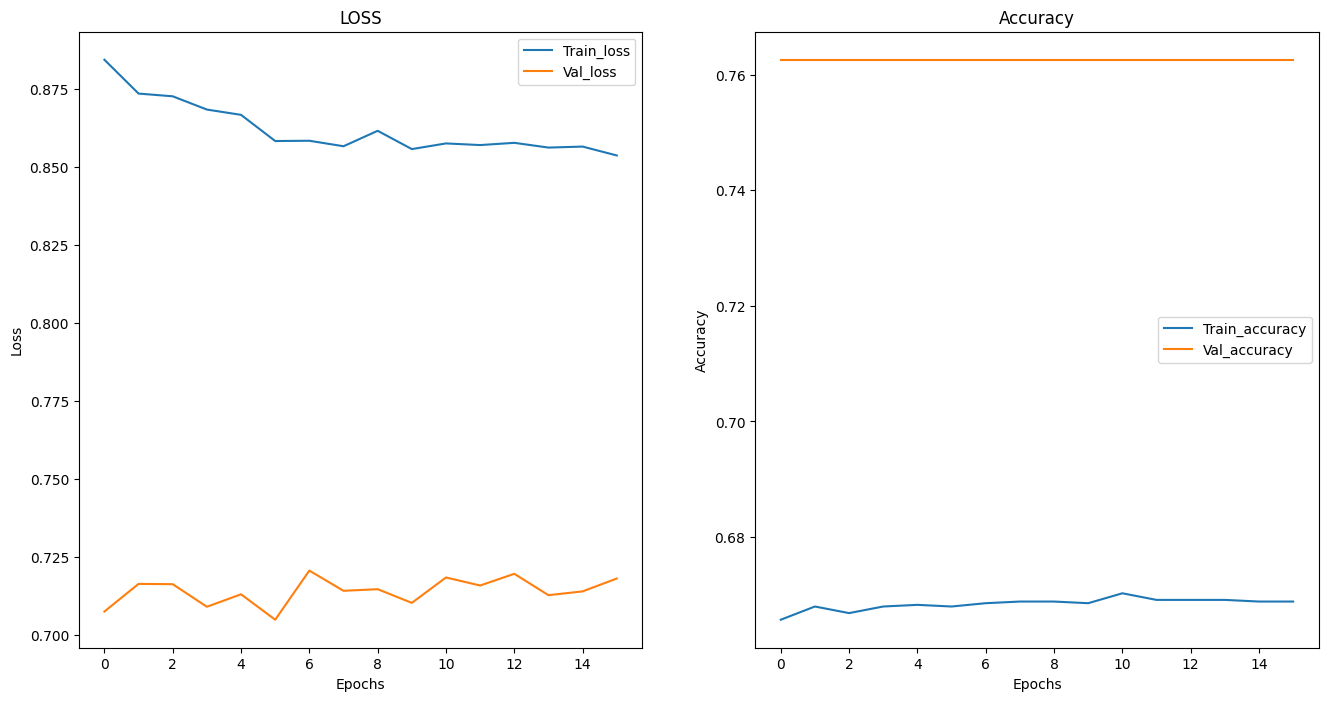

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train_loss')
plt.plot(history.history['val_loss'], label='Val_loss')
plt.title('LOSS')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train_accuracy')
plt.plot(history.history['val_accuracy'], label='Val_accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

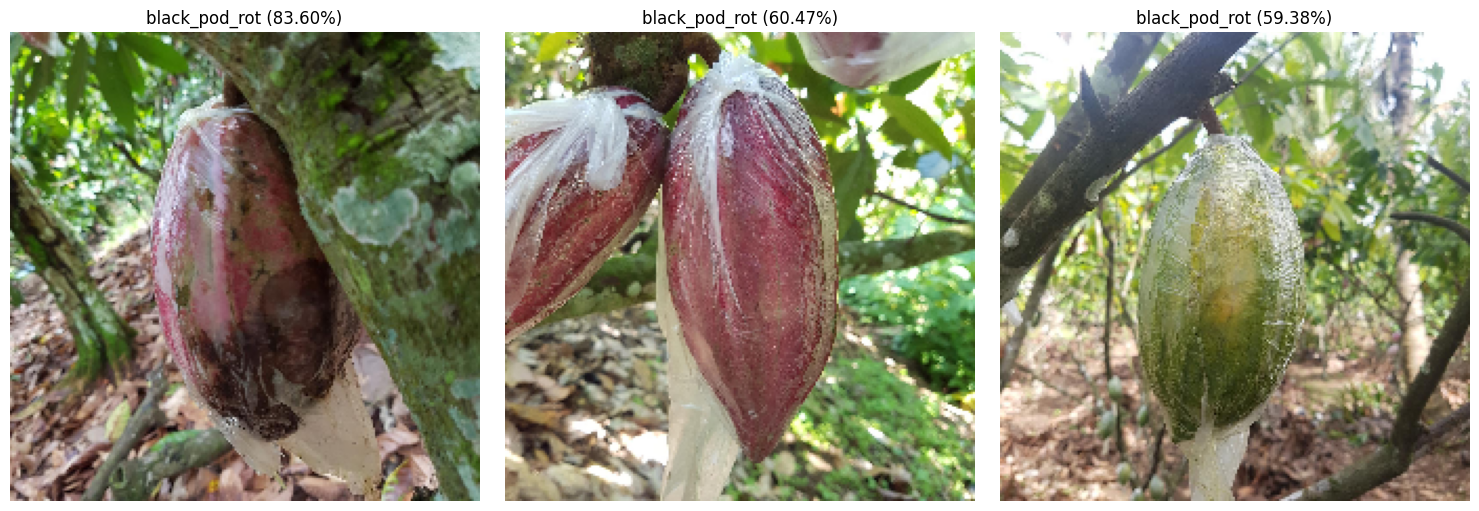

In [16]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

# --- Thông tin ---
# --- Cấu hình ---
img_paths = [
    "/kaggle/working/cacao_split/test/black_pod_rot/black_pod_rot_104.jpg",
    "/kaggle/working/cacao_split/test/healthy/healthy_1096.jpg",
    "/kaggle/working/cacao_split/test/pod_borer/pod_borer_96.jpg"
]
class_names = ['pod_borer', 'black_pod_rot', 'healthy']

# --- Tiền xử lý & Dự đoán ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, path in enumerate(img_paths):
    # Load ảnh
    img = tf.keras.utils.load_img(path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_batch)

    # Dự đoán
    preds = model.predict(img_preprocessed, verbose=0)[0]  # model phải là mô hình có Dense(4, softmax)
    pred_class_idx = np.argmax(preds)
    pred_class_name = class_names[pred_class_idx]
    confidence = preds[pred_class_idx]

    # Hiển thị
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{pred_class_name} ({confidence*100:.2f}%)")

plt.tight_layout()
plt.show()
